Augmentation Testing for Hand.

Removing flip augmentation from model training data.

In [ ]:
# Mount Google Drive
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Set up dataset path
os.chdir("drive/My Drive/")
spreadsheet_path = "Auslan Static Dataset Breakdown"
dataset_path = "AuslanStaticData"

Mounted at /content/drive


In [ ]:
# Authorise access to Google sheets
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()

gc = gspread.authorize(creds)

In [ ]:
import pandas as pd

# Open sheets
worksheet = gc.open('Auslan Static Dataset Breakdown').sheet1

# Get all values from the worksheet
rows = worksheet.get_all_values()

# Convert to DataFrame with first row as column names
spreadsheet = pd.DataFrame(rows[1:], columns=rows[0])

# Confirm format
print(spreadsheet)

     ID Subject         Date            Device        Filename Class Lighting  \
0     0    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_0_1.jpg     0  Natural   
1     1    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_1_1.jpg     1  Natural   
2     2    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_2_1.jpg     2  Natural   
3     3    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_3_1.jpg     3  Natural   
4     4    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_4_1.jpg     4  Natural   
...  ..     ...          ...               ...             ...   ...      ...   
4729       Nick  Apr 29 2025         iPhone 12  Nick_u_114.JPG     u  Natural   
4730       Nick  Apr 29 2025         iPhone 12  Nick_u_115.JPG     u  Natural   
4731       Nick  Apr 29 2025         iPhone 12  Nick_u_116.JPG     u  Natural   
4732       Nick  Apr 29 2025         iPhone 12  Nick_u_117.JPG     u  Natural   
4733       Nick  Apr 29 2025         iPhone 12  Nick_u_118.JPG     u  Natural   

     Light level           

In [ ]:
# Cross reference Drive dataset with Sheets datalist

# Get list of files
file_list = os.listdir(dataset_path)

# Convert to DataFrame
drive_files = pd.DataFrame(file_list, columns=['Filename'])

set1 = set(drive_files['Filename'])
set2 = set(spreadsheet["Filename"])

# Find missing files
missing_in_df2 = set1 - set2  # Files in df1 but not in df2
missing_in_df1 = set2 - set1  # Files in df2 but not in df1

print("Files missing in Spreadsheet:", missing_in_df2)
print("Files missing in Drive folder:", missing_in_df1)

print(set1)
print(set2)

Files missing in Spreadsheet: {'Evelyn_1_58.jpeg'}
Files missing in Drive folder: set()
{'Nick_7_102.jpg', 'Daniel_c_3.jpg', 'Daniel_8_6.jpg', 'Luke_9_6.jpg', 'Evelyn_u_14.jpg', 'Daniel_a_26.jpg', 'Evelyn_9_33.jpg', 'Daniel_e_34.jpg', 'Nick_2_3.jpg', 'Luke_7_6.jpg', 'Nick_8_89.jpg', 'Evelyn_o_68.jpg', 'Evelyn_7_55.jpeg', 'Evelyn_3_74.jpg', 'Evelyn_9_48.JPG', 'Nick_o_96.jpg', 'Nick_u_93.jpg', 'Daniel_a_15.jpg', 'Luke_1_30.jpg', 'Nick_5_69.jpg', 'Daniel_e_29.jpg', 'Evelyn_o_25.jpg', 'Evelyn_5_63.jpg', 'Luke_0_10.jpg', 'Nick_o_76.JPG', 'Nick_5_88.jpg', 'Evelyn_2_9.jpg', 'Nick_4_52.jpg', 'Nick_4_70.jpg', 'Nick_u_87.jpg', 'Evelyn_u_51.JPG', 'Nick_8_37.jpg', 'Luke_4_19.jpg', 'Evelyn_3_25.jpg', 'Nick_i_36.jpg', 'Nick_3_116.JPG', 'Luke_i_7.jpg', 'Luke_6_17.jpg', 'Luke_k_5.jpg', 'Evelyn_2_39.jpg', 'Evelyn_6_68.jpg', 'Evelyn_7_69.jpg', 'Nick_i_64.jpg', 'Evelyn_8_26.jpg', 'Luke_u_23.jpg', 'Daniel_e_12.jpg', 'Nick_7_59.jpg', 'Nick_2_37.jpg', 'Evelyn_3_38.jpg', 'Daniel_5_47.jpg', 'Nick_e_19.jpg', '

In [ ]:
# Select independent testing variable

# Testing class
# Subject, Device, Light level, Lighting, Background, Skin Tone, Distance, Orientation, Away from body, Clothing
testing_class = "Hand"

# Sub-class
# subject: Daniel, Evelyn, Luke, Nick
# device: Dell XPS 15 9050, Iphone
# light_level: Dark, Medium, Bright
# light_colour: Natural, Warm, Cold
# background: Plain, Somewhat/mostly plain, not_plain
# skin_tone: Brown, White, Tan
# distance: Close, Medium, Far
# orientation: Direct, Indirect
# body: Yes, No
# clothing: Light, Dark
# hand: Left, Right
independent_variable = "Left"

In [ ]:
# Create training and testing datasets that include and exclude specific images
import os
import pandas as pd
import shutil

vowel_numbers = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'e', 'i', 'o', 'u']

# Files excluding independent variable
spreadsheet_reduced = spreadsheet[spreadsheet['Class'].isin(vowel_numbers)]

images_without_var = spreadsheet_reduced[spreadsheet_reduced[testing_class] != independent_variable]
images_var = spreadsheet_reduced[spreadsheet_reduced[testing_class] == independent_variable]

filenames_without_var = images_without_var["Filename"]
filenames_var = images_var["Filename"]
all_filenames = spreadsheet_reduced["Filename"]

# Split data into training, validation, and testing sets
training_images_without_var = filenames_without_var.sample(frac=0.7)
remaining_images_without_var = filenames_without_var.drop(training_images_without_var.index)
validation_images_without_var = remaining_images_without_var.sample(frac=0.5)
testing_images_without_var = remaining_images_without_var.drop(validation_images_without_var.index)

training_images_with_var = filenames_var.sample(frac=0.7)
remaining_images_with_var = filenames_var.drop(training_images_with_var.index)
validation_images_with_var = remaining_images_with_var.sample(frac=0.5)
testing_images_only_var = remaining_images_with_var.drop(validation_images_with_var.index)
training_images_with_var = pd.concat([training_images_with_var, training_images_without_var], ignore_index=True)
validation_images_with_var = pd.concat([validation_images_with_var, validation_images_without_var], ignore_index=True) # combined validation set with var and without var
testing_images_mixed = pd.concat([testing_images_only_var, testing_images_without_var], ignore_index=True)

In [ ]:
# Extract class of image from filename
import re

def class_finder(filename):
    match = re.search(r'_(\w)_', filename)  # Extract the character between underscores
    if not match:
        raise ValueError("Filename format incorrect. Expected format: 'prefix_<char>_suffix'")

    extractFileClass = match.group(1)  # Get the matched class

    # Mapping for vowels
    class_map = {'a': 10, 'e': 11, 'i': 12, 'o': 13, 'u': 14}

    # Check if it's a digit
    if extractFileClass.isdigit():
        return int(extractFileClass)  # Convert string number to int
    elif extractFileClass in class_map:
        return class_map[extractFileClass]  # Map vowel to number
    else:
        raise ValueError(f"Unknown class: {extractFileClass}")  # Handle invalid cases

def label_generator(dataset_filenames):
    labels = []
    for filename in dataset_filenames:
        labels.append(class_finder(filename))
    return labels


In [ ]:
# Generate label sets for data
import tensorflow as tf

label_training_no_var = label_generator(training_images_without_var)
label_testing_no_var = label_generator(testing_images_without_var)
label_validation_no_var = label_generator(validation_images_without_var)

label_training_no_var = tf.keras.utils.to_categorical(label_training_no_var, num_classes=15)
label_testing_no_var = tf.keras.utils.to_categorical(label_testing_no_var, num_classes=15)
label_validation_no_var = tf.keras.utils.to_categorical(label_validation_no_var, num_classes=15)

print(training_images_without_var)
print(label_training_no_var)

label_training_var = label_generator(training_images_with_var)
label_testing_var = label_generator(testing_images_only_var)
label_validation_var = label_generator(validation_images_with_var)
label_testing_mixed = label_generator(testing_images_mixed)

label_training_var = tf.keras.utils.to_categorical(label_training_var, num_classes=15)
label_testing_var = tf.keras.utils.to_categorical(label_testing_var, num_classes=15)
label_validation_var = tf.keras.utils.to_categorical(label_validation_var, num_classes=15)
label_testing_mixed = tf.keras.utils.to_categorical(label_testing_mixed, num_classes=15)

1541      Nick_a_15.jpg
3589      Luke_5_34.jpg
3623      Luke_9_36.jpg
4277    Evelyn_o_69.jpg
3511      Luke_2_29.jpg
             ...       
4323    Evelyn_u_72.jpg
2123    Daniel_i_16.jpg
2849      Nick_3_59.jpg
4690     Nick_7_114.JPG
3279      Luke_a_13.jpg
Name: Filename, Length: 2045, dtype: object
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [ ]:
# Create TF datasets from PD dataframes
def load_image(image_path):
    img = tf.io.read_file(os.path.join("AuslanStaticData", image_path.numpy().decode())) # Decode the image path from bytes to string
    img = tf.image.decode_jpeg(img, channels=3) # Decode the image
    img = tf.image.resize(img, [224, 224]) # Resize the image to your desired size
    img = tf.cast(img, tf.float32) # Cast the image to float32
    img = img / 255.0 # Normalize the pixel values to [0, 1]
    return img

def load_image_wrapper(image_path):
    img = tf.py_function(load_image, [image_path], Tout=tf.float32)
    img.set_shape([224, 224, 3])  # Set the shape immediately
    return img


In [ ]:
# Create TensorFlow datasets from data and labels.
import tensorflow as tf
import tensorflow_datasets as tfds

no_variable_training = tf.data.Dataset.from_tensor_slices((training_images_without_var.values, label_training_no_var)) # Create a dataset from the paths and labels
no_variable_training = no_variable_training.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
no_variable_training = no_variable_training.batch(32).prefetch(tf.data.AUTOTUNE) # Added batching and prefetching

variable_training = tf.data.Dataset.from_tensor_slices((training_images_with_var.values, label_training_var)) # Create a dataset from the paths and labels
variable_training = variable_training.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
variable_training = variable_training.batch(32).prefetch(tf.data.AUTOTUNE) # Added batching and prefetching

# Create testing datasets
validation_var_dataset = tf.data.Dataset.from_tensor_slices((validation_images_with_var.values, label_validation_var))  # Replace validation_labels with appropriate label data
validation_var_dataset = validation_var_dataset.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
validation_var_dataset = validation_var_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

validation_no_var_dataset = tf.data.Dataset.from_tensor_slices((validation_images_without_var.values, label_validation_no_var))  # Replace validation_labels with appropriate label data
validation_no_var_dataset = validation_no_var_dataset.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
validation_no_var_dataset = validation_no_var_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

variable_testing = tf.data.Dataset.from_tensor_slices((testing_images_only_var.values, label_testing_var)) # Create a dataset from the paths and labels
variable_testing = variable_testing.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
variable_testing = variable_testing.batch(32).prefetch(tf.data.AUTOTUNE) # Added batching and prefetching

mixed_testing = tf.data.Dataset.from_tensor_slices((testing_images_mixed.values, label_testing_mixed)) # Create a dataset from the paths and labels
mixed_testing = mixed_testing.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
mixed_testing = mixed_testing.batch(32).prefetch(tf.data.AUTOTUNE) # Added batching and prefetching

no_variable_testing = tf.data.Dataset.from_tensor_slices((testing_images_without_var.values, label_testing_no_var)) # Create a dataset from the paths and labels
no_variable_testing = no_variable_testing.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
no_variable_testing = no_variable_testing.batch(32).prefetch(tf.data.AUTOTUNE) # Added batching and prefetching


In [ ]:
# Augment training datasets
def add_random_noise_with_factor(image, label):
    # Generate noise with mean 0 and stddev 1 (or adjust as needed)
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=1.0, dtype=tf.float32)

    # Generate a random noise_factor between 0.2 and 0.5
    noise_factor = tf.random.uniform(shape=[], minval=0.2, maxval=0.5)

    # Apply the noise with the random factor
    noisy_image = image + noise * noise_factor

    # Clip the pixel values to be within the valid range [0, 1]
    noisy_image = tf.clip_by_value(noisy_image, clip_value_min=0.0, clip_value_max=1.0)

    return noisy_image, label

var_flip_dataset = variable_training.map(lambda image, label: (tf.image.stateless_random_flip_left_right(image, seed=(1,2)), label))  # Added seed argument
var_brightness_dataset = variable_training.map(lambda image, label: (tf.image.random_brightness(image, max_delta=0.1), label))
var_contrast_dataset = variable_training.map(lambda image, label: (tf.image.random_contrast(image, 0.8, 1.2), label))
var_saturation_dataset = variable_training.map(lambda image, label: (tf.image.random_saturation(image, 0.8, 1.2), label))
var_noise_dataset = variable_training.map(add_random_noise_with_factor, num_parallel_calls=tf.data.AUTOTUNE)

no_var_flip_dataset = no_variable_training.map(lambda image, label: (tf.image.stateless_random_flip_left_right(image, seed=(1,2)), label))  # Added seed argument
no_var_brightness_dataset = no_variable_training.map(lambda image, label: (tf.image.random_brightness(image, max_delta=0.1), label))
no_var_contrast_dataset = no_variable_training.map(lambda image, label: (tf.image.random_contrast(image, 0.8, 1.2), label))
no_var_saturation_dataset = no_variable_training.map(lambda image, label: (tf.image.random_saturation(image, 0.8, 1.2), label))
no_var_noise_dataset = no_variable_training.map(add_random_noise_with_factor, num_parallel_calls=tf.data.AUTOTUNE)

aug_no_var_training = tf.data.Dataset.sample_from_datasets([no_variable_training, no_var_noise_dataset, no_var_brightness_dataset, no_var_contrast_dataset, no_var_saturation_dataset])
aug_var_training = tf.data.Dataset.sample_from_datasets([variable_training, var_noise_dataset, var_brightness_dataset, var_contrast_dataset, var_saturation_dataset])

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping

# Define input shape based on dataset
IMG_SHAPE = (224, 224, 3)

base_model_no_var = VGG16(weights="imagenet", include_top=False, input_shape=IMG_SHAPE)
base_model_no_var.trainable = True

# Freeze most of the base model
for layer in base_model_no_var.layers[:-4]:
    layer.trainable = False

# Define model_no_var with its own base model
model_no_var = models.Sequential([
    base_model_no_var,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(15, activation='softmax')
    ])

model_no_var.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

learning_rate = 0.00016043268

optimizer_no_var = tf.keras.optimizers.Adam(learning_rate=learning_rate)

model_no_var.compile(
    optimizer=optimizer_no_var,
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

es_no_var = EarlyStopping(monitor='val_accuracy', mode='max', patience=5,  restore_best_weights=True)
model_no_var.fit(aug_no_var_training, epochs=50, batch_size=32,validation_data=validation_no_var_dataset, callbacks=[es_no_var])

base_model_var = VGG16(weights="imagenet", include_top=False, input_shape=IMG_SHAPE)
base_model_var.trainable = True

# Freeze most of the base model
for layer in base_model_var.layers[:-4]:
    layer.trainable = False

# Define model_var with its own base model
model_var = models.Sequential([
    base_model_var,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(15, activation='softmax')
    ])

learning_rate = 0.00016043268

optimizer_var = tf.keras.optimizers.Adam(learning_rate=learning_rate)

model_var.compile(
    optimizer=optimizer_var,
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

es_var = EarlyStopping(monitor='val_accuracy', mode='max', patience=5,  restore_best_weights=True)
model_var.fit(aug_var_training, epochs=50, batch_size=32,validation_data=validation_var_dataset, callbacks=[es_var])



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/50
    320/Unknown 207s 581ms/step - accuracy: 0.1295 - loss: 3.3897

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


320/320 ━━━━━━━━━━━━━━━━━━━━ 219s 619ms/step - accuracy: 0.1297 - loss: 3.3886 - val_accuracy: 0.3562 - val_loss: 2.2143
Epoch 2/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 61s 189ms/step - accuracy: 0.3783 - loss: 2.1494 - val_accuracy: 0.6324 - val_loss: 1.3977
Epoch 3/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 60s 188ms/step - accuracy: 0.6657 - loss: 1.4050 - val_accuracy: 0.7443 - val_loss: 1.1108
Epoch 4/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 61s 189ms/step - accuracy: 0.7969 - loss: 1.0630 - val_accuracy: 0.7945 - val_loss: 0.9337
Epoch 5/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 61s 189ms/step - accuracy: 0.8460 - loss: 0.8819 - val_accuracy: 0.8196 - val_loss: 0.9261
Epoch 6/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 61s 189ms/step - accuracy: 0.8773 - loss: 0.7731 - val_accuracy: 0.7922 - val_loss: 1.0270
Epoch 7/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 61s 189ms/step - accuracy: 0.8852 - loss: 0.7139 - val_accuracy: 0.8174 - val_loss: 0.9536
Epoch 8/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 60s 188ms/step - accuracy: 0.8862 - loss: 0.6760 - va

In [ ]:
# Produce confusion matrix for included model tested on independent variable
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Predict on the test set using the model
pred_var_var = model_var.predict(variable_testing, verbose=1)
pred_var_novar = model_var.predict(no_variable_testing, verbose=1)
pred_var_mixed = model_var.predict(mixed_testing, verbose=1)

pred_novar_var = model_no_var.predict(variable_testing, verbose=1)
pred_novar_novar = model_no_var.predict(no_variable_testing, verbose=1)
pred_novar_mixed = model_no_var.predict(mixed_testing, verbose=1)

# Get the predicted labels by taking the index of the maximum probability for each image
pred_var_var_labels = np.argmax(pred_var_var, axis=1)
pred_var_novar_labels = np.argmax(pred_var_novar, axis=1)
pred_var_mixed_labels = np.argmax(pred_var_mixed, axis=1)
pred_novar_var_labels = np.argmax(pred_novar_var, axis=1)
pred_novar_novar_labels = np.argmax(pred_novar_novar, axis=1)
pred_novar_mixed_labels = np.argmax(pred_novar_mixed, axis=1)

# Get the true labels from the test set generator
pred_var_var_true = np.concatenate([y.numpy() for _, y in variable_testing.unbatch()])
pred_var_novar_true = np.concatenate([y.numpy() for _, y in no_variable_testing.unbatch()])
pred_var_mixed_true = np.concatenate([y.numpy() for _, y in mixed_testing.unbatch()])

pred_novar_var_true = np.concatenate([y.numpy() for _, y in variable_testing.unbatch()])
pred_novar_novar_true = np.concatenate([y.numpy() for _, y in no_variable_testing.unbatch()])
pred_novar_mixed_true = np.concatenate([y.numpy() for _, y in mixed_testing.unbatch()])

# Reshape into (N, 36) where N is inferred
pred_var_var_true = pred_var_var_true.reshape(-1, 15)
pred_var_novar_true = pred_var_novar_true.reshape(-1, 15)
pred_var_mixed_true = pred_var_mixed_true.reshape(-1, 15)
pred_novar_var_true = pred_novar_var_true.reshape(-1, 15)
pred_novar_novar_true = pred_novar_novar_true.reshape(-1, 15)
pred_novar_mixed_true = pred_novar_mixed_true.reshape(-1, 15)

# Apply argmax to get class labels
pred_var_var_true = np.argmax(pred_var_var_true, axis=1)
pred_var_novar_true = np.argmax(pred_var_novar_true, axis=1)
pred_var_mixed_true = np.argmax(pred_var_mixed_true, axis=1)
pred_novar_var_true = np.argmax(pred_novar_var_true, axis=1)
pred_novar_novar_true = np.argmax(pred_novar_novar_true, axis=1)
pred_novar_mixed_true = np.argmax(pred_novar_mixed_true, axis=1)

# Generate the confusion matrix
cm_var_var = confusion_matrix(pred_var_var_true, pred_var_var_labels)
cm_var_novar = confusion_matrix(pred_var_novar_true, pred_var_novar_labels)
cm_var_mixed = confusion_matrix(pred_var_mixed_true, pred_var_mixed_labels)
cm_novar_var = confusion_matrix(pred_novar_var_true, pred_novar_var_labels)
cm_novar_novar = confusion_matrix(pred_novar_novar_true, pred_novar_novar_labels)
cm_novar_mixed = confusion_matrix(pred_novar_mixed_true, pred_novar_mixed_labels)

6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 377ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 221ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 324ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 229ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 211ms/step


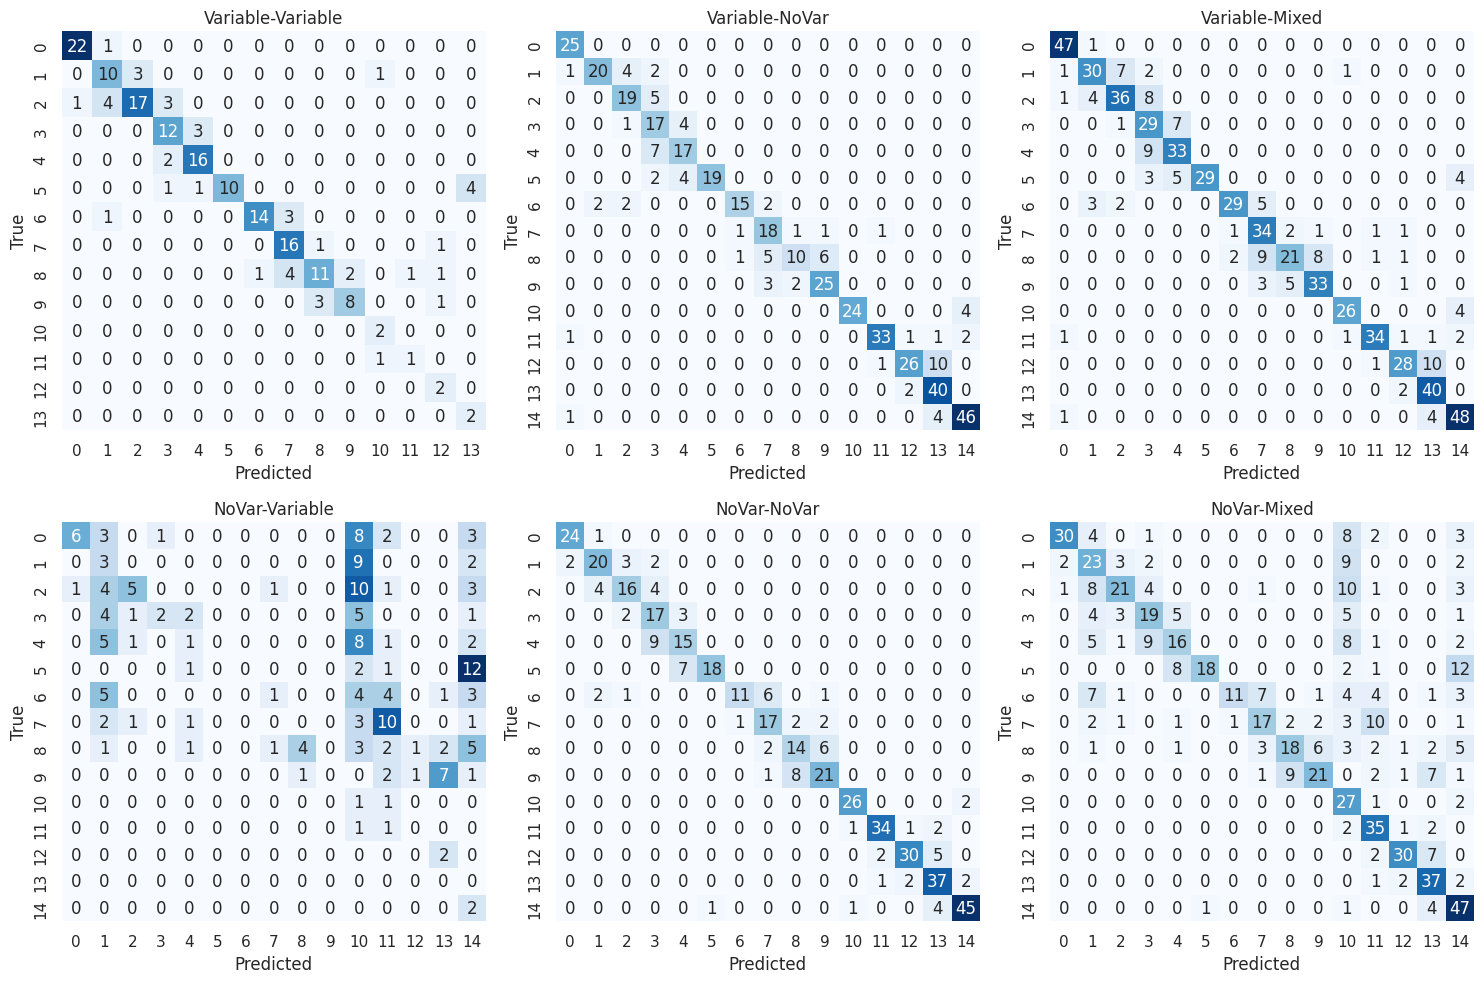

In [ ]:
# Define the confusion matrices and titles for plotting
confusion_matrices = [cm_var_var, cm_var_novar, cm_var_mixed,
                      cm_novar_var, cm_novar_novar, cm_novar_mixed]
titles = ['Variable-Variable', 'Variable-NoVar', 'Variable-Mixed',
          'NoVar-Variable', 'NoVar-NoVar', 'NoVar-Mixed']

# Create a 2x3 grid for plotting
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Loop over each subplot and confusion matrix to plot
for ax, cm, title in zip(axes.flatten(), confusion_matrices, titles):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=[str(i) for i in range(cm.shape[1])],
                yticklabels=[str(i) for i in range(cm.shape[0])])
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
print("Var - Var")
print(classification_report(pred_var_var_true, pred_var_var_labels))
print("Var - No Var")
print(classification_report(pred_var_novar_true, pred_var_novar_labels))
print("Var - Mixed")
print(classification_report(pred_var_mixed_true, pred_var_mixed_labels))
print("No Var - Var")
print(classification_report(pred_novar_var_true, pred_novar_var_labels))
print("No Var - No Var")
print(classification_report(pred_novar_novar_true, pred_novar_novar_labels))
print("No Var - Mixed")
print(classification_report(pred_novar_mixed_true, pred_novar_mixed_labels))

Var - Var
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        23
           1       0.62      0.71      0.67        14
           2       0.85      0.68      0.76        25
           3       0.67      0.80      0.73        15
           4       0.80      0.89      0.84        18
           5       1.00      0.62      0.77        16
           6       0.93      0.78      0.85        18
           7       0.70      0.89      0.78        18
           8       0.73      0.55      0.63        20
           9       0.80      0.67      0.73        12
          10       0.50      1.00      0.67         2
          11       0.50      0.50      0.50         2
          12       0.40      1.00      0.57         2
          14       0.33      1.00      0.50         2

    accuracy                           0.76       187
   macro avg       0.70      0.79      0.71       187
weighted avg       0.80      0.76      0.77       187

Var - No Var
  

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_